In [88]:
import pandas as pd
import re
import statistics as st
from scipy import stats # библиотека для расчетов
import plotly.express as px
import matplotlib.pyplot as plt # библиотека визуализации
import category_encoders as ce
import seaborn as sns
import numpy as np
from sklearn import preprocessing
heart=pd.read_csv('heart.csv')
heart['old'] = heart['age'].apply(lambda x: 1 if x>60 else 0)
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0,1
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0,0


In [89]:
heart['old'].sum()

79

In [90]:
def age_enc(x):
    if x<20: return 1
    elif 20<x<31: return 2
    elif 30<x<41: return 3
    elif 40<x<51: return 4
    elif 50<x<61: return 5
    else: return 6
    
heart['age_enc'] = heart['age'].apply(age_enc).astype('int32')
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
 14  old       303 non-null    int64  
 15  age_enc   303 non-null    int32  
dtypes: float64(1), int32(1), int64(14)
memory usage: 36.8 KB


In [91]:
presure=pd.read_csv('presure.csv',sep=';')
ord_encoder = ce.OrdinalEncoder()
data_bin = ord_encoder.fit_transform(presure[['age']])
col_names = list(presure.columns)
col_names.append('age_enc')
presure = pd.DataFrame(pd.concat([presure, data_bin], axis=1))
presure = presure.set_axis(col_names, axis=1, inplace=False)
heart=pd.merge(heart, presure, how='left', on='age_enc')
heart


C:\Users\lepni\AppData\Local\Temp\ipykernel_13688\2804825517.py:7: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  presure = presure.set_axis(col_names, axis=1, inplace=False)


,age_x,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old,age_enc,age_y,male,female
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1,6,61+,142,159
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0,3,31-40,129,127
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0,4,41-50,135,137
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0,5,51-60,142,144
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0,5,51-60,142,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,0,5,51-60,142,144
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0,0,4,41-50,135,137
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0,1,6,61+,142,159
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0,0,5,51-60,142,144


In [92]:
heart['trestbps_mean']=np.NaN
for i in range(len(heart.index)):
    if heart['sex'][i]==1: heart['trestbps_mean'][i]=heart['male'][i]
    else: heart['trestbps_mean'][i]=heart['female'][i]
heart=heart.drop(['male', 'female', 'age_y'], axis=1)
heart['trestbps_mean']=heart['trestbps_mean'].astype('int32')

C:\Users\lepni\AppData\Local\Temp\ipykernel_13688\2675844089.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if heart['sex'][i]==1: heart['trestbps_mean'][i]=heart['male'][i]
C:\Users\lepni\AppData\Local\Temp\ipykernel_13688\2675844089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  else: heart['trestbps_mean'][i]=heart['female'][i]


In [93]:
heart['trestbps_mean'][300]

142

In [94]:
encoder = ce.OneHotEncoder(cols=['cp', 'restecg', 'slope', 'ca', 'thal'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(heart[['cp','restecg','slope','ca','thal']])
df = pd.DataFrame(pd.concat([heart, type_bin], axis=1))
df=df.drop(['cp','restecg','slope','ca','thal','age_enc'],axis=1)
df


,age_x,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,old,...,slope_1.0,ca_0.0,ca_2.0,ca_1.0,ca_3.0,ca_4.0,thal_1.0,thal_2.0,thal_3.0,thal_0.0
0,63,1,145,233,1,150,0,2.3,1,1,...,0,1,0,0,0,0,1,0,0,0
1,37,1,130,250,0,187,0,3.5,1,0,...,0,1,0,0,0,0,0,1,0,0
2,41,0,130,204,0,172,0,1.4,1,0,...,0,1,0,0,0,0,0,1,0,0
3,56,1,120,236,0,178,0,0.8,1,0,...,0,1,0,0,0,0,0,1,0,0
4,57,0,120,354,0,163,1,0.6,1,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,123,1,0.2,0,0,...,1,1,0,0,0,0,0,0,1,0
299,45,1,110,264,0,132,0,1.2,0,0,...,1,1,0,0,0,0,0,0,1,0
300,68,1,144,193,1,141,0,3.4,0,1,...,1,0,1,0,0,0,0,0,1,0
301,57,1,130,131,0,115,1,1.2,0,0,...,1,0,0,1,0,0,0,0,1,0


,chol
count,303.000000
mean,0.098646
std,0.816232
min,-1.795276
25%,-0.456693
50%,0.000000
75%,0.543307
max,5.102362


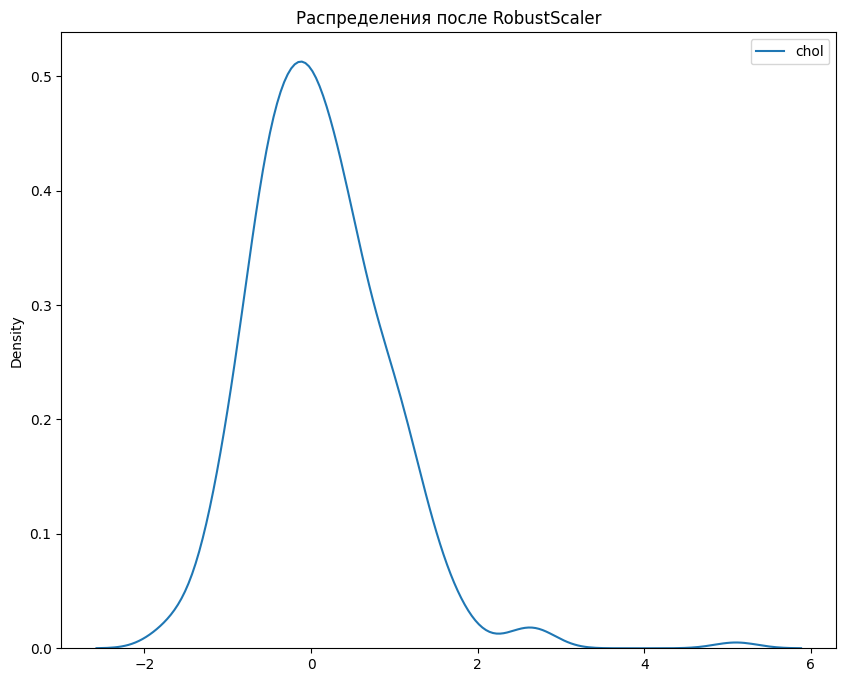

In [95]:
r_scaler = preprocessing.RobustScaler()
df_r=pd.DataFrame(df['chol'])
col_names = list(df_r.columns)
df_r = r_scaler.fit_transform(df_r)
df_r = pd.DataFrame(df_r, columns=col_names)
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после RobustScaler')

sns.kdeplot(df_r, ax=ax1)
df_r.describe()

<AxesSubplot: >

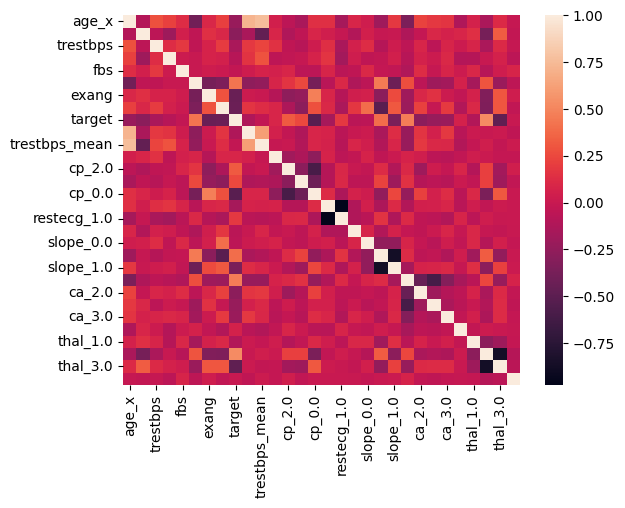

In [98]:
sns.heatmap(df.corr())